--- AVVIO FASE A : CARICAMENTO DEL DATASET , PREPROCESSING , SUDDIVISIONE DEL DATASET IN TEST E TRAIN---
Numero di record presenti nel dataset: 32561
Colonne con valori mancanti: ['workclass', 'occupation', 'native.country']
Numero di record rimossi: 2399


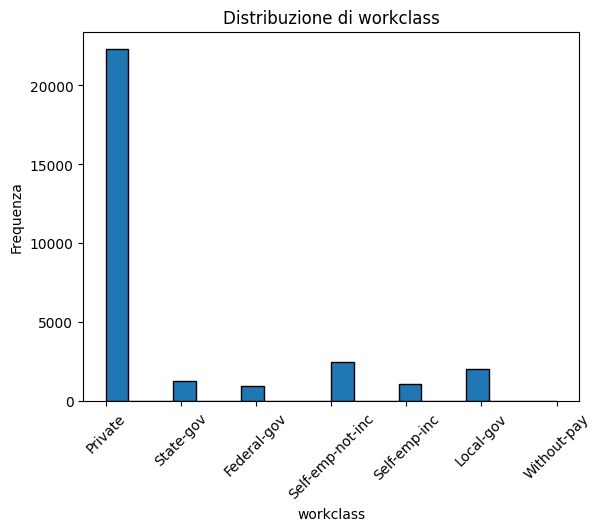

Colonne numeriche: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Colonne categoriche: ['workclass', 'occupation', 'race', 'sex', 'native.country']


C:\Users\franc\AppData\Local\Temp\ipykernel_59680\384336842.py:75: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report , confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Funzione per il raggruppamento della categoria workclass in categorie più ampie

def group_workclass(val):
    if val in ['Federal-gov', 'Local-gov', 'State-gov']:
        return 'Government'
    elif val in ['Self-emp-inc', 'Self-emp-not-inc']:
        return 'Self-Employed'
    else :
        return val


print("--- AVVIO FASE A : CARICAMENTO DEL DATASET , PREPROCESSING , SUDDIVISIONE DEL DATASET IN TEST E TRAIN---")

# Caricamento del dataset conversione del file csv in un DataFrame pandas 
df = pd.read_csv('adult.csv' , skipinitialspace=True , sep=',')

# Mostriamo in output il numero di record presenti nel dataset
dim_dataset = len(df)
print(f"Numero di record presenti nel dataset: {dim_dataset}")

# Sostituiamo i valori '?' con NaN per facilitare l'identificazione dei valori mancanti
df=df.replace('?', pd.NA)

# restituiamo in output le colonne del dataset con valori mancanti
print("Colonne con valori mancanti:", df.columns[df.isnull().any()].tolist())

# Eliminazione di record con valori mancanti
df = df.dropna()

# Ritorinamo il numero di colonne del dataset che sono state rimosse
print(f"Numero di record rimossi: {dim_dataset - len(df)}")

#rimozione della colonna education in quanto ridondante con la colonna education-num
df = df.drop(columns=['education'])

df = df.drop(columns=['relationship','marital.status'])



# Mostriamo istogramma della distribuzione dei valori presenti nella colonna workclass
plt.hist(df['workclass'], bins=20, edgecolor='black')
plt.title('Distribuzione di workclass')
plt.xlabel('workclass')
plt.ylabel('Frequenza')
plt.xticks(rotation=45)
plt.show()

# Raggruppamento della colonna workclass in categorie più ampie migliora la regressione logistica ma non Random Forest
df['workclass'] = df['workclass'].apply(group_workclass)

# X data frame senza la colonna target 'income'
X = df.drop('income', axis=1)

# y vettore target binario
y = df['income'].apply(lambda x: 1 if '>50K' in x else 0)

# Identifichiamo colonne numeriche e categoriche
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
print("Colonne numeriche:", [col for col in numeric_features])
categorical_features = X.select_dtypes(include=['object']).columns
print("Colonne categoriche:", [col for col in categorical_features])

# Suddivisione del dataset in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42) 


# applichiamo lo scaling alle caratteristiche numeriche e one-hot encoding a quelle categoriche
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
# applichiamo lo scaling alle caratteristiche numeriche e one-hot encoding a quelle categoriche
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


--- AVVIO FASE B : ADDESTRAMENTO DEI MODELLI E VALUTAZIONE ---
Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      4533
           1       0.53      0.76      0.62      1500

    accuracy                           0.77      6033
   macro avg       0.72      0.77      0.73      6033
weighted avg       0.81      0.77      0.78      6033



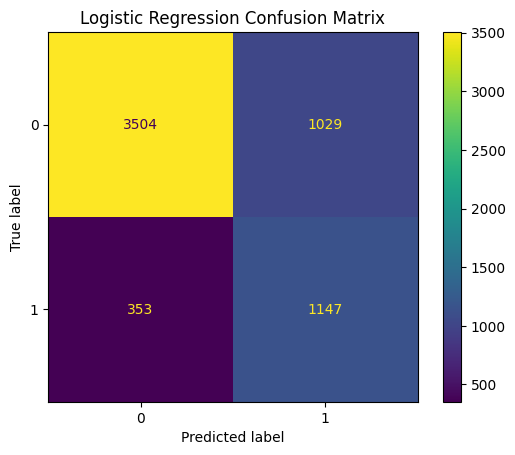

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      4533
           1       0.57      0.77      0.66      1500

    accuracy                           0.80      6033
   macro avg       0.74      0.79      0.76      6033
weighted avg       0.83      0.80      0.81      6033



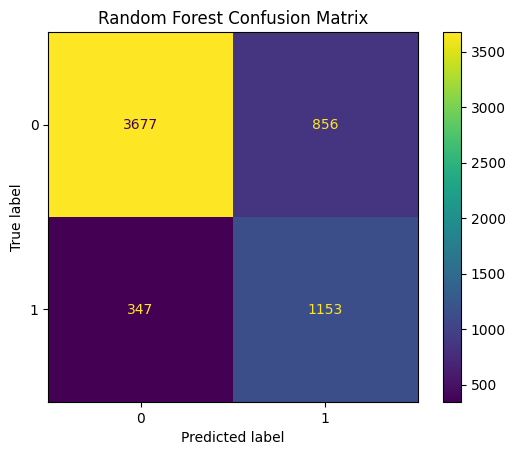

SVM Performance:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84      4533
           1       0.53      0.79      0.64      1500

    accuracy                           0.78      6033
   macro avg       0.73      0.78      0.74      6033
weighted avg       0.82      0.78      0.79      6033



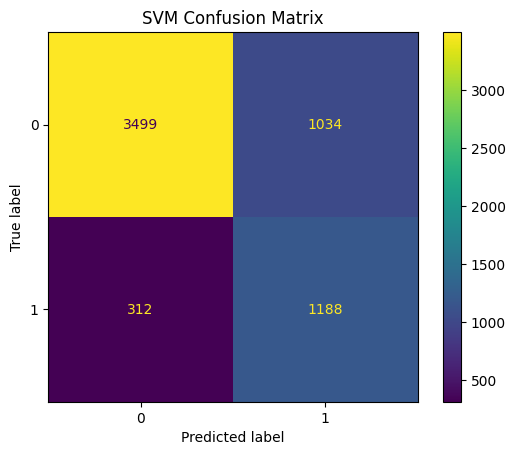

In [2]:
print("--- AVVIO FASE B : ADDESTRAMENTO DEI MODELLI E VALUTAZIONE ---")

# Addestramento di tutti i modelli
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20, class_weight='balanced',random_state=42,min_samples_split=5,min_samples_leaf=2),
    "SVM": SVC(kernel='rbf', class_weight='balanced',random_state=42)
}

# Ciclo di addestramento e valutazione
for name, model in models.items():
    model.fit(X_train_preprocessed, y_train) # Allenamento
    y_pred = model.predict(X_test_preprocessed) # Predizione
    print(f"{name} Performance:") 
    print(classification_report(y_test, y_pred)) # Valutazione
    cm = confusion_matrix(y_test, y_pred) # Matrice di confusione
    ConfusionMatrixDisplay(cm).plot() # Visualizzazione matrice di confusione
    plt.title(f"{name} Confusion Matrix")
    plt.show()

--- AVVIO FASE C1 : ANALISI DI GENERE , CALCOLO DELLE METRICHE DI FAIRNESS---
Predizioni per Logistic Regression - Analisi di genere:
Disparate Impact: 0.264
Equal Opportunity Difference: -0.329

Predizioni per Random Forest - Analisi di genere:
Disparate Impact: 0.185
Equal Opportunity Difference: -0.371

Predizioni per SVM - Analisi di genere:
Disparate Impact: 0.189
Equal Opportunity Difference: -0.398



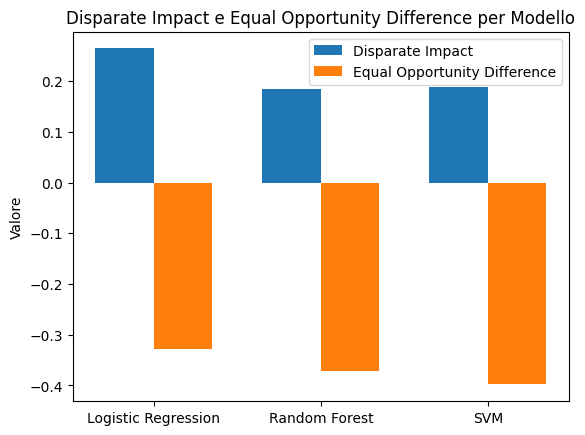

In [3]:
print("--- AVVIO FASE C1 : ANALISI DI GENERE , CALCOLO DELLE METRICHE DI FAIRNESS---")

# Funzione per calcolare selection rate e true positive rate
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    selection_rate = (tp + fp) / (tn + fp + fn + tp)
    tpr = tp / (tp + fn)
    return selection_rate, tpr

disparate_impact_sex = []
equal_opportunity_diff_sex = []
labels_sex=[]

# Creazione maschere per uomini e donne
mask_male = (X_test['sex'] == 'Male')
mask_female = (X_test['sex'] == 'Female')

X_testM= X_test[mask_male]
X_testF= X_test[mask_female]
X_testM = preprocessor.transform(X_testM)
X_testF = preprocessor.transform(X_testF)

y_testM = y_test[mask_male]
y_testF = y_test[mask_female]

# Predizioni per ogni modello e calcolo delle metriche di fairness
for name, model in models.items():
    print(f"Predizioni per {name} - Analisi di genere:")
    y_pred_M= model.predict(X_testM)
    y_pred_F= model.predict(X_testF)
    sr_donne, tpr_donne = get_metrics(y_testF, y_pred_F)
    sr_uomini, tpr_uomini = get_metrics(y_testM, y_pred_M)
    disparate_impact = sr_donne / sr_uomini if sr_uomini > 0 else 0
    equal_opportunity_diff = tpr_donne - tpr_uomini
    disparate_impact_sex.append(disparate_impact)
    equal_opportunity_diff_sex.append(equal_opportunity_diff)
    labels_sex.append(name)
    print(f"Disparate Impact: {disparate_impact:.3f}")
    print(f"Equal Opportunity Difference: {equal_opportunity_diff:.3f}")
    print()    

#Lanciamo una visualizzazione grafica di disparate impact e equal opportunity difference per i modelli
x = np.arange(len(labels_sex))  # posizione delle barre
width = 0.35  # larghezza delle barre
plt.bar(x - width/2, disparate_impact_sex, width, label='Disparate Impact')
plt.bar(x + width/2, equal_opportunity_diff_sex, width, label='Equal Opportunity Difference')
plt.xticks(x, labels_sex)
plt.ylabel('Valore')
plt.title('Disparate Impact e Equal Opportunity Difference per Modello')
plt.legend()
plt.show()



--- AVVIO FASE C2 : ANALISI DI RAZZA , CALCOLO DELLE METRICHE DI FAIRNESS ---
Predizioni per Logistic Regression - Analisi di razza:
Disparate Impact: 0.550
Equal Opportunity Difference: -0.132

Predizioni per Random Forest - Analisi di razza:
Disparate Impact: 0.484
Equal Opportunity Difference: -0.144

Predizioni per SVM - Analisi di razza:
Disparate Impact: 0.571
Equal Opportunity Difference: -0.099



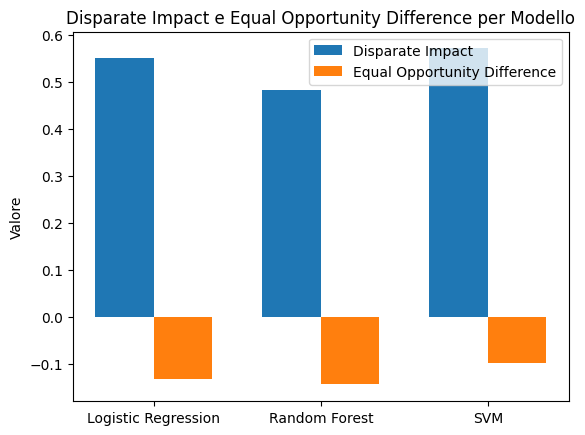

In [4]:
print("--- AVVIO FASE C2 : ANALISI DI RAZZA , CALCOLO DELLE METRICHE DI FAIRNESS ---")

disparate_impact_race = []
equal_opportunity_diff_race = []
labels_race=[]

# Creazione maschere per bianchi e altri
mask_white = (X_test['race'] == 'White')
mask_other = (X_test['race'] != 'White')

X_testW= X_test[mask_white]
X_testO= X_test[mask_other]
X_testW = preprocessor.transform(X_testW)
X_testO = preprocessor.transform(X_testO)

y_testW = y_test[mask_white]
y_testO = y_test[mask_other]

# Predizioni per ogni modello e calcolo delle metriche di fairness
for name, model in models.items():
    print(f"Predizioni per {name} - Analisi di razza:")
    y_pred_W= model.predict(X_testW)
    y_pred_O= model.predict(X_testO)
    sr_White, tpr_White = get_metrics(y_testW, y_pred_W)
    sr_Other, tpr_Other = get_metrics(y_testO, y_pred_O)
    disparate_impact = sr_Other / sr_White if sr_White > 0 else 0
    equal_opportunity_diff = tpr_Other - tpr_White
    disparate_impact_race.append(disparate_impact)
    equal_opportunity_diff_race.append(equal_opportunity_diff)
    labels_race.append(name)
    print(f"Disparate Impact: {disparate_impact:.3f}")
    print(f"Equal Opportunity Difference: {equal_opportunity_diff:.3f}")
    print()    

#Lanciamo una visualizzazione grafica di disparate impact e equal opportunity difference per i modelli
x = np.arange(len(labels_race))  # posizione delle barre
width = 0.35  # larghezza delle barre
plt.bar(x - width/2, disparate_impact_race, width, label='Disparate Impact')
plt.bar(x + width/2, equal_opportunity_diff_race, width, label='Equal Opportunity Difference')
plt.xticks(x, labels_race)
plt.ylabel('Valore')
plt.title('Disparate Impact e Equal Opportunity Difference per Modello')
plt.legend()
plt.show()



--- AVVIO FASE D: STUDIO DI ABLATION E IMPORTANZA FEATURE ---


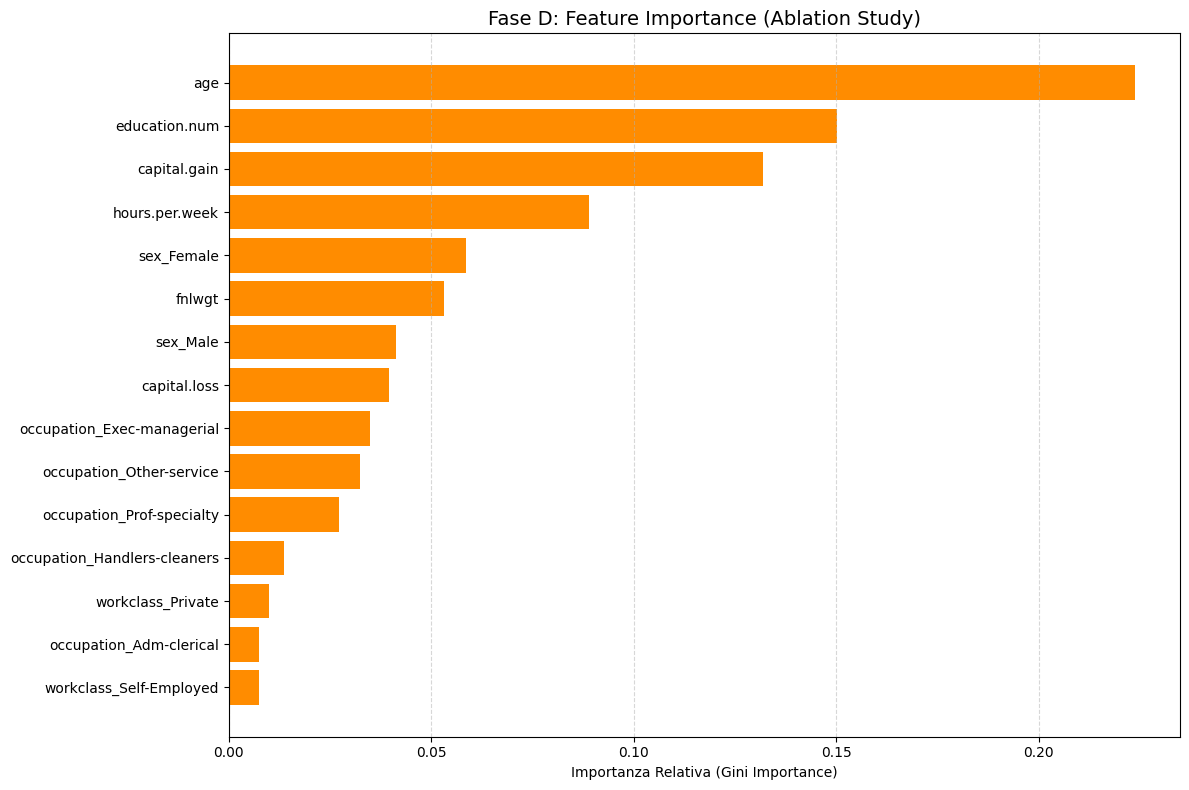

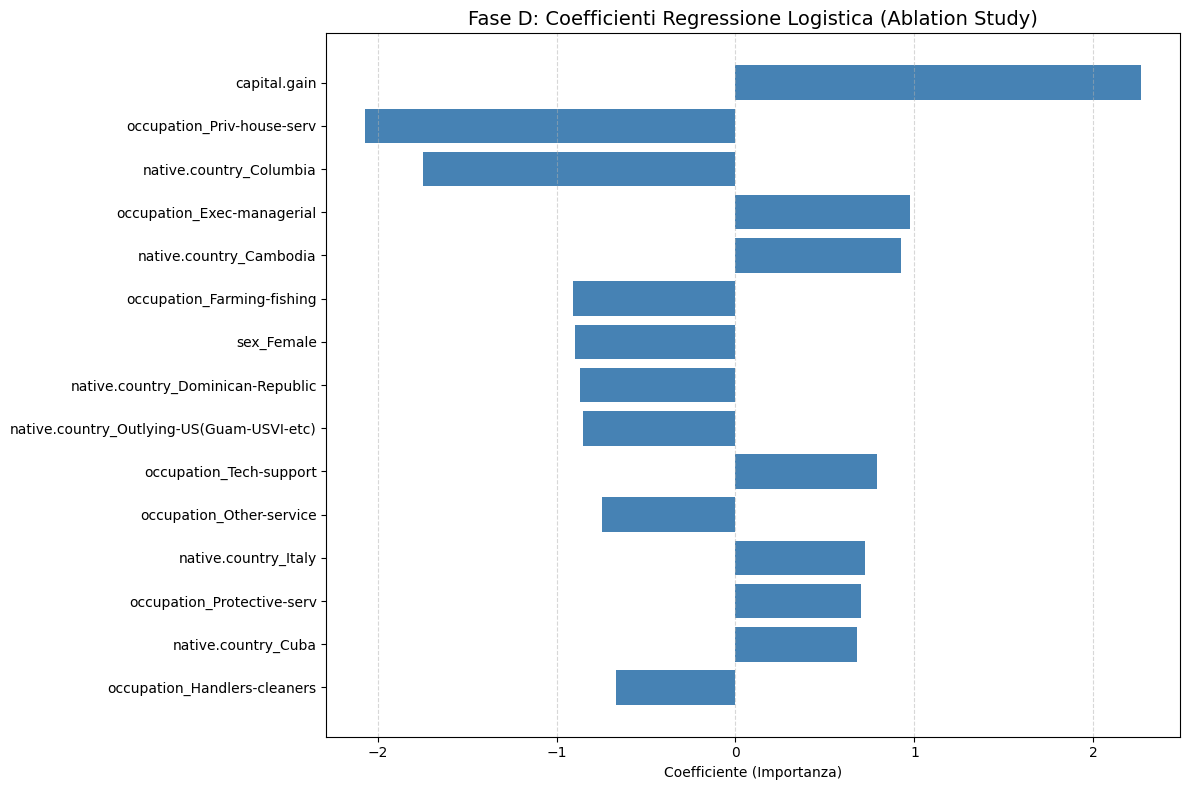

Analisi: La feature più influente è 'age'.


In [5]:
print("--- AVVIO FASE D: STUDIO DI ABLATION E IMPORTANZA FEATURE ---")

# 1. Recupero nomi delle feature post-preprocessing
feature_names = preprocessor.get_feature_names_out()

# Pulizia dei nomi (rimuove i prefissi 'num__' e 'cat__')
clean_names = [n.split('__')[1] if '__' in n else n for n in feature_names]

# 2. Estrazione Feature Importance dalla Random Forest
importances = models["Random Forest"].feature_importances_
indices = np.argsort(importances)[-15:] # Prendiamo le prime 15
# 3- Estrazione coefficienti dalla Regressione Logistica
coef_lr = models["Logistic Regression"].coef_[0]
indices_lr = np.argsort(np.abs(coef_lr))[-15:]

# 3. Visualizzazione random forest
plt.figure(figsize=(12, 8))
plt.title('Fase D: Feature Importance (Ablation Study)', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='darkorange', align='center')
plt.yticks(range(len(indices)), [clean_names[i] for i in indices])
plt.xlabel('Importanza Relativa (Gini Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. Visualizzazione regressione logistica
plt.figure(figsize=(12, 8))
plt.title('Fase D: Coefficienti Regressione Logistica (Ablation Study)', fontsize=14)
plt.barh(range(len(indices_lr)), coef_lr[indices_lr], color='steelblue', align='center')
plt.yticks(range(len(indices_lr)), [clean_names[i] for i in indices_lr])
plt.xlabel('Coefficiente (Importanza)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 4. Analisi dei risultati 
top_feature = clean_names[indices[-1]]
print(f"Analisi: La feature più influente è '{top_feature}'.")
